# Classification multi‑label des interactions avec CYP450 (CYP3A4, CYP2C9, CYP2D6)

Dans ce notebook, nous allons charger et modéliser plusieurs jeux de données TDC pour prédire l’inhibition des principaux isoenzymes CYP450 : CYP2C19, CYP2D6, CYP3A4, CYP1A2 et CYP2C9. Pour chacun :

- **Task** : classification binaire (1 = inhibiteur, 0 = non‑inhibiteur)  
- **Featurisation** : ECFP4 (Morgan radius=2, 2048 bits)  
- **Splits** : Random Split & Scaffold Split  
- **Référence** :  
  > Veith, H. et al. *Comprehensive characterization of cytochrome P450 isozyme selectivity across chemical libraries.* Nature Biotech. 27, 1050–1055 (2009). 

In [1]:
import sys
# Ajoute le parent du dossier notebooks (le root de ton projet) au PYTHONPATH
sys.path.append('..')


## 1) Chargement de tous les jeux TDC CYP450

Nous allons télécharger les cinq jeux Veith pour les isoenzymes CYP450 via **TDC** et afficher le nombre de composés en train/test.


In [2]:
# %% [code]
from tdc.single_pred import ADME

dataset_names = [
    'CYP2C19_Veith',
    'CYP2D6_Veith',
    'CYP3A4_Veith',
    'CYP1A2_Veith',
    'CYP2C9_Veith'
]

splits = {}
for name in dataset_names:
    print(f"🔄 Chargement de {name} …")
    data = ADME(name=name)
    split = data.get_split()   # {'train': DataFrame, 'test': DataFrame}
    # On inspecte vite les colonnes
    print("   ▶️ train columns :", split['train'].columns.tolist())
    # On comptabilise
    n_train = split['train'].shape[0]
    n_test  = split['test'].shape[0]
    print(f"   ▶️ {name}: {n_train} train, {n_test} test\n")
    splits[name] = split


Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!


🔄 Chargement de CYP2C19_Veith …
   ▶️ train columns : ['Drug_ID', 'Drug', 'Y']
   ▶️ CYP2C19_Veith: 8866 train, 2533 test

🔄 Chargement de CYP2D6_Veith …
   ▶️ train columns : ['Drug_ID', 'Drug', 'Y']
   ▶️ CYP2D6_Veith: 9191 train, 2626 test

🔄 Chargement de CYP3A4_Veith …
   ▶️ train columns : ['Drug_ID', 'Drug', 'Y']
   ▶️ CYP3A4_Veith: 8629 train, 2466 test

🔄 Chargement de CYP1A2_Veith …
   ▶️ train columns : ['Drug_ID', 'Drug', 'Y']
   ▶️ CYP1A2_Veith: 8805 train, 2516 test

🔄 Chargement de CYP2C9_Veith …
   ▶️ train columns : ['Drug_ID', 'Drug', 'Y']
   ▶️ CYP2C9_Veith: 8465 train, 2418 test



In [3]:
# %% [code]
import pandas as pd
from src.preprocessing import process_smiles, compute_ecfp4

def featurize(split):
    """
    Prend split={'train':DF,'test':DF} avec colonnes ['Drug','Y'], 
    renvoie X_train,y_train,X_test,y_test en utilisant ECFP4.
    """
    # 1) Renommer
    df_tr = split['train'].rename(columns={'Drug':'smiles','Y':'y'}).copy()
    df_te = split['test'] .rename(columns={'Drug':'smiles','Y':'y'}).copy()

    # 2) Nettoyage & fingerprint
    for df, label in [(df_tr,'train'), (df_te,'test')]:
        df['smiles_clean'] = df['smiles'].map(process_smiles)
        removed = df['smiles_clean'].isna().sum()
        df.dropna(subset=['smiles_clean'], inplace=True)
        print(f"   • {label}: {len(df)} SMILES valides (–{removed})")
        df['fp'] = df['smiles_clean'].map(compute_ecfp4)

    # 3) Construit X / y
    Xtr = pd.DataFrame(df_tr['fp'].tolist(), index=df_tr.index)
    ytr = df_tr['y'].astype(int)
    Xte = pd.DataFrame(df_te['fp'].tolist(), index=df_te.index)
    yte = df_te['y'].astype(int)
    return Xtr, ytr, Xte, yte

# %% [code]
# Itération sur tous les jeux CYP Veith
feature_sets = {}
for name, split in splits.items():
    print(f"\n🔄 Featurisation de {name} …")
    X_train, y_train, X_test, y_test = featurize(split)
    print(f"   ▶️ {name} shapes : X_train={X_train.shape}, X_test={X_test.shape}\n")
    feature_sets[name] = (X_train, y_train, X_test, y_test)



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/data/home/aboussif/venv/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/data/home/aboussif/venv/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/data/home/aboussif/venv/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 739, in start
    self.io_loop.start()
  File "/data

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/data/home/aboussif/venv/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/data/home/aboussif/venv/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/data/home/aboussif/venv/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 739, in start
    self.io_loop.start()
  File "/data

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/data/home/aboussif/venv/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/data/home/aboussif/venv/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/data/home/aboussif/venv/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 739, in start
    self.io_loop.start()
  File "/data

...


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/data/home/aboussif/venv/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/data/home/aboussif/venv/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/data/home/aboussif/venv/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 739, in start
    self.io_loop.start()
  File "/data

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/data/home/aboussif/venv/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/data/home/aboussif/venv/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/data/home/aboussif/venv/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 739, in start
    self.io_loop.start()
  File "/data

AttributeError: _ARRAY_API not found


🔄 Featurisation de CYP2C19_Veith …
   • train: 8866 SMILES valides (–0)
   • test: 2533 SMILES valides (–0)
   ▶️ CYP2C19_Veith shapes : X_train=(8866, 2048), X_test=(2533, 2048)


🔄 Featurisation de CYP2D6_Veith …
   • train: 9191 SMILES valides (–0)
   • test: 2626 SMILES valides (–0)
   ▶️ CYP2D6_Veith shapes : X_train=(9191, 2048), X_test=(2626, 2048)


🔄 Featurisation de CYP3A4_Veith …
   • train: 8629 SMILES valides (–0)
   • test: 2466 SMILES valides (–0)
   ▶️ CYP3A4_Veith shapes : X_train=(8629, 2048), X_test=(2466, 2048)


🔄 Featurisation de CYP1A2_Veith …
   • train: 8805 SMILES valides (–0)
   • test: 2516 SMILES valides (–0)
   ▶️ CYP1A2_Veith shapes : X_train=(8805, 2048), X_test=(2516, 2048)


🔄 Featurisation de CYP2C9_Veith …
   • train: 8465 SMILES valides (–0)
   • test: 2418 SMILES valides (–0)
   ▶️ CYP2C9_Veith shapes : X_train=(8465, 2048), X_test=(2418, 2048)



Pour chaque isoforme P450 (CYP2C19, 2D6, 3A4, 1A2, 2C9),  
on dispose d’un split `split = ADME(name=…)`  
ayant `split['train']` et `split['test']` avec colonnes `Drug` et `Y`.  
Nous avons déjà – via la cellule précédente – featurisé en ECFP4 et stocké  
les matrices `X_train, X_test` et vecteurs `y_train, y_test` dans `feature_sets[name]`.

On va maintenant :

- Afficher la **répartition** des classes  
- Entraîner **SGD, LogisticRegression, RandomForest, SVM**  
- Évaluer : accuracy, precision, recall, f1, ROC‑AUC, PR‑AUC, MCC  
- Tracer (optionnel) les courbes ROC/PR  
- Stocker les scores dans un DataFrame récapitulatif



## 🔬 Isoforme: CYP2C19_Veith
  • Train labels: 0→4803, 1→4063,  ratio = 0.46
  •  Test labels: 0→1370, 1→1163,  ratio = 0.46

--- SGD ---
Metrics for Pipeline:
    accuracy: 0.730
   precision: 0.715
      recall: 0.684
          f1: 0.699
     roc_auc: 0.787
      pr_auc: 0.749
         mcc: 0.455


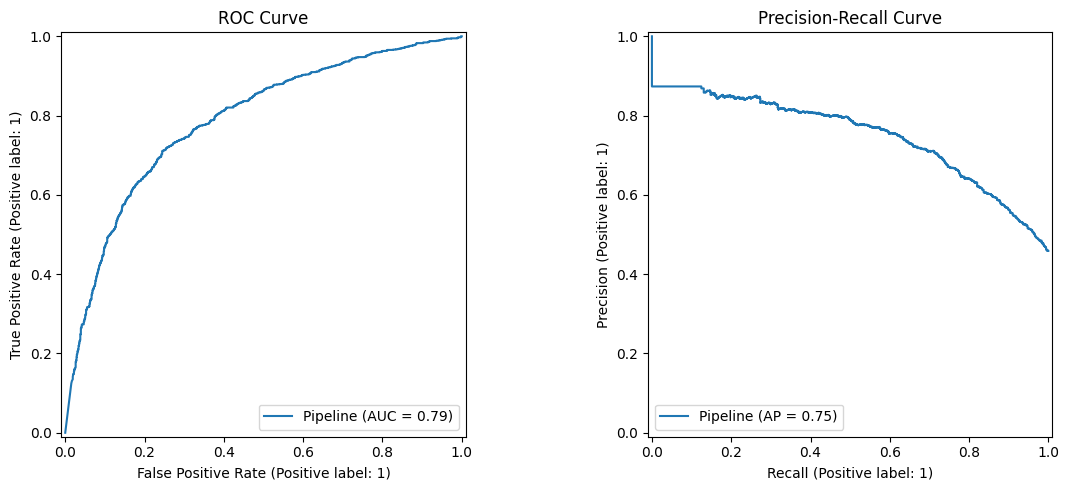

--- LogReg ---
Metrics for Pipeline:
    accuracy: 0.745
   precision: 0.729
      recall: 0.707
          f1: 0.718
     roc_auc: 0.801
      pr_auc: 0.764
         mcc: 0.485


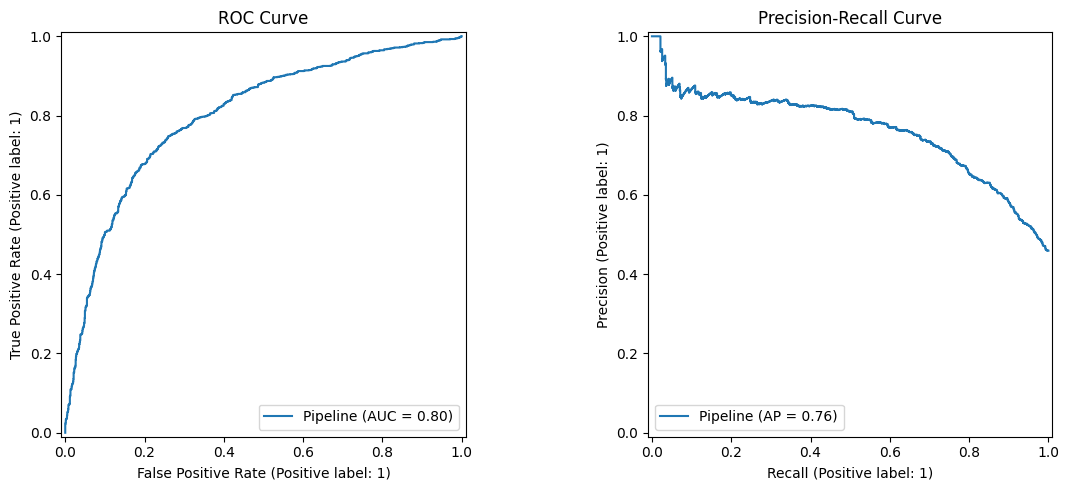

--- RF ---
Metrics for RandomForestClassifier:
    accuracy: 0.806
   precision: 0.769
      recall: 0.824
          f1: 0.796
     roc_auc: 0.876
      pr_auc: 0.842
         mcc: 0.612


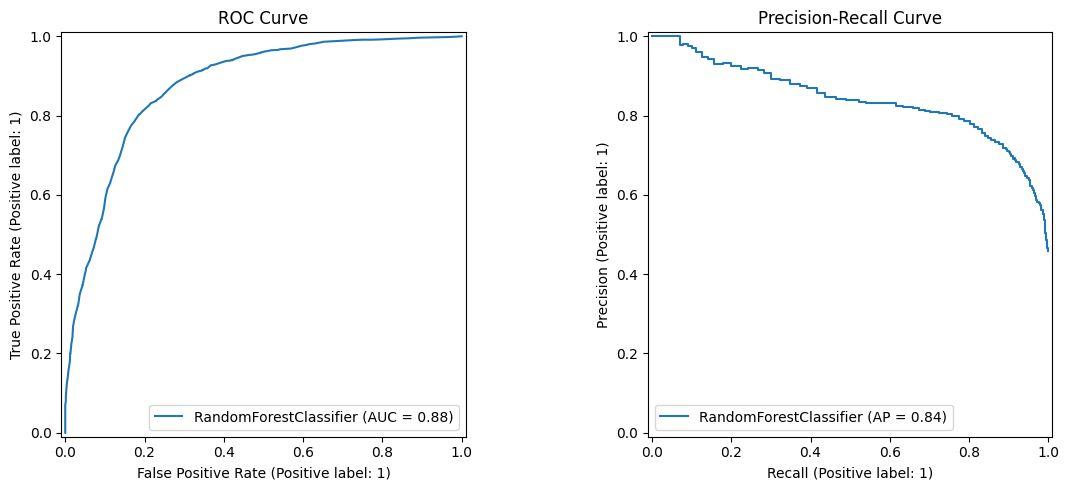


Feature importances:


1750    0.018798
1088    0.011309
1683    0.007673
1152    0.006419
1199    0.006384
          ...   
1201    0.000015
793     0.000014
1830    0.000013
756     0.000012
1467    0.000011
Length: 2048, dtype: float64

--- SVM ---
Metrics for Pipeline:
    accuracy: 0.807
   precision: 0.789
      recall: 0.789
          f1: 0.789
     roc_auc: 0.880
      pr_auc: 0.845
         mcc: 0.611


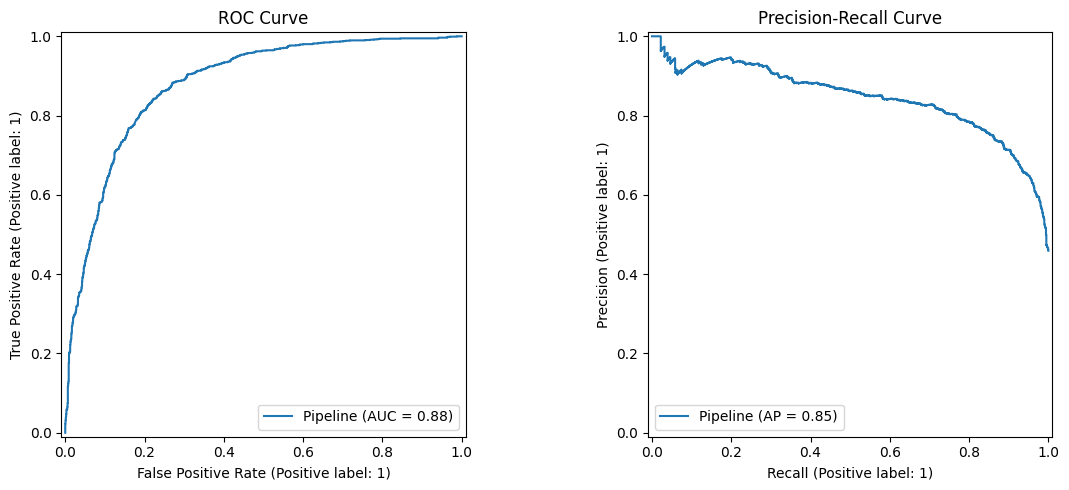


## 🔬 Isoforme: CYP2D6_Veith
  • Train labels: 0→7425, 1→1766,  ratio = 0.19
  •  Test labels: 0→2138, 1→488,  ratio = 0.19

--- SGD ---
Metrics for Pipeline:
    accuracy: 0.817
   precision: 0.507
      recall: 0.533
          f1: 0.519
     roc_auc: 0.778
      pr_auc: 0.443
         mcc: 0.407


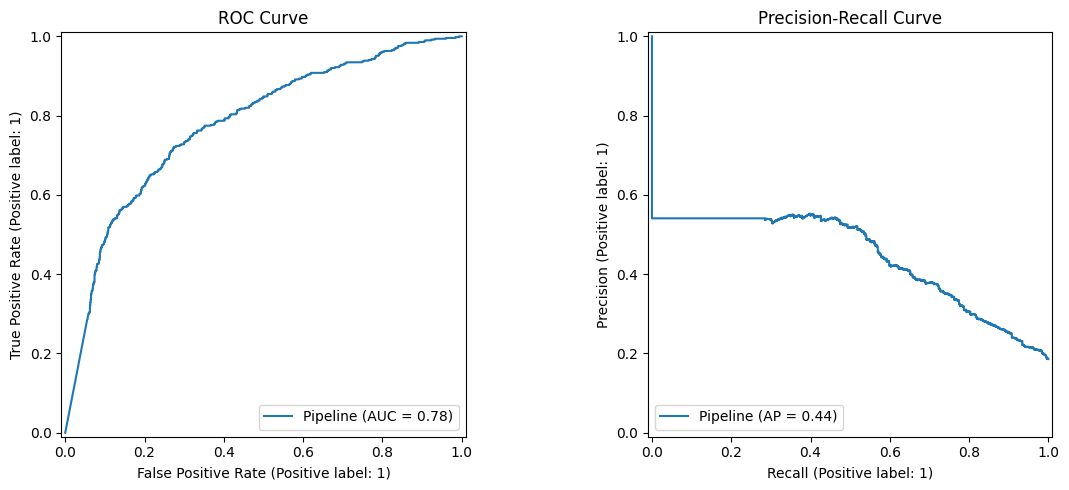

--- LogReg ---
Metrics for Pipeline:
    accuracy: 0.813
   precision: 0.496
      recall: 0.570
          f1: 0.531
     roc_auc: 0.775
      pr_auc: 0.459
         mcc: 0.416


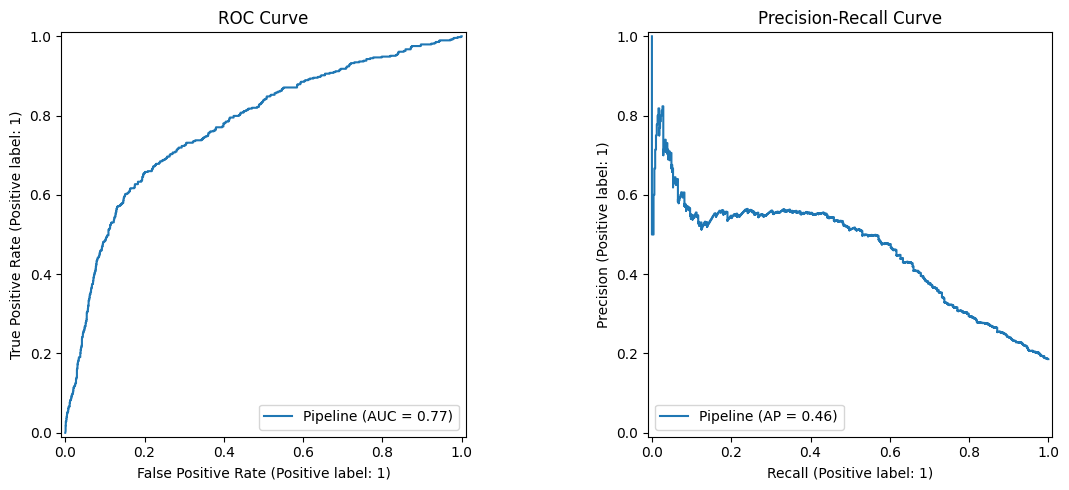

--- RF ---
Metrics for RandomForestClassifier:
    accuracy: 0.867
   precision: 0.803
      recall: 0.375
          f1: 0.511
     roc_auc: 0.860
      pr_auc: 0.669
         mcc: 0.489


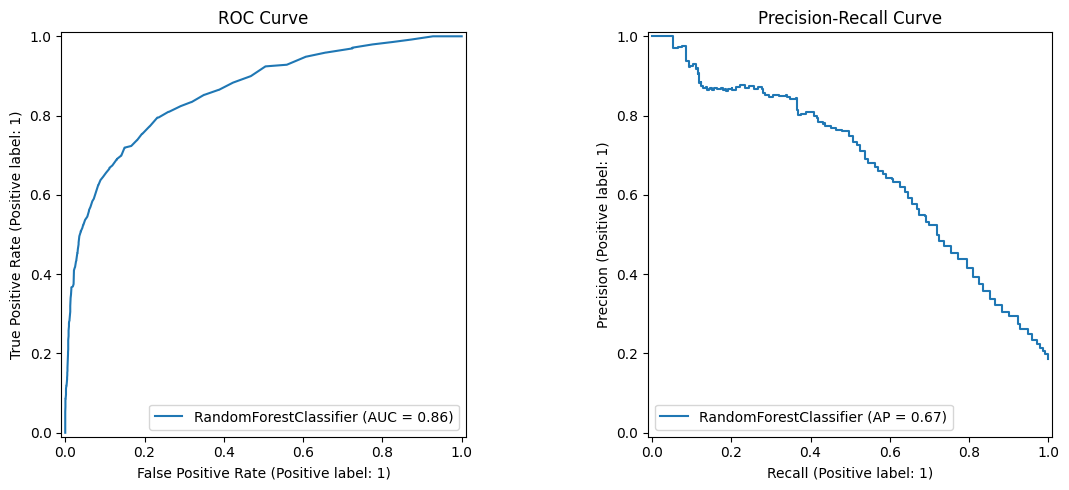


Feature importances:


650     1.902696e-02
1791    9.348450e-03
1349    8.415089e-03
314     8.182149e-03
1917    5.352288e-03
            ...     
1491    4.558990e-06
1639    2.786836e-06
187     1.514939e-06
601     1.356257e-06
1263    3.677238e-07
Length: 2048, dtype: float64

--- SVM ---
Metrics for Pipeline:
    accuracy: 0.869
   precision: 0.829
      recall: 0.369
          f1: 0.511
     roc_auc: 0.856
      pr_auc: 0.672
         mcc: 0.497


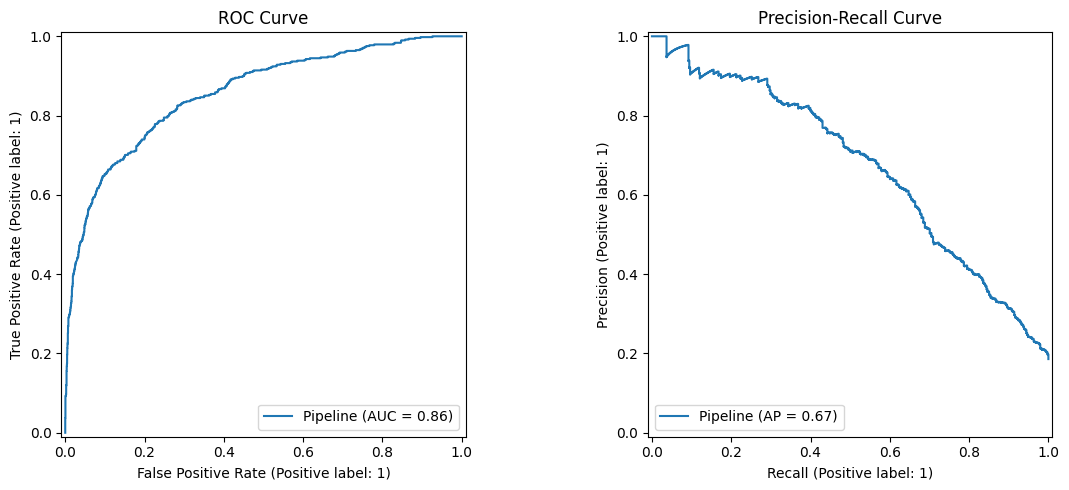


## 🔬 Isoforme: CYP3A4_Veith
  • Train labels: 0→5052, 1→3577,  ratio = 0.41
  •  Test labels: 0→1449, 1→1017,  ratio = 0.41

--- SGD ---
Metrics for Pipeline:
    accuracy: 0.748
   precision: 0.684
      recall: 0.724
          f1: 0.703
     roc_auc: 0.806
      pr_auc: 0.722
         mcc: 0.485


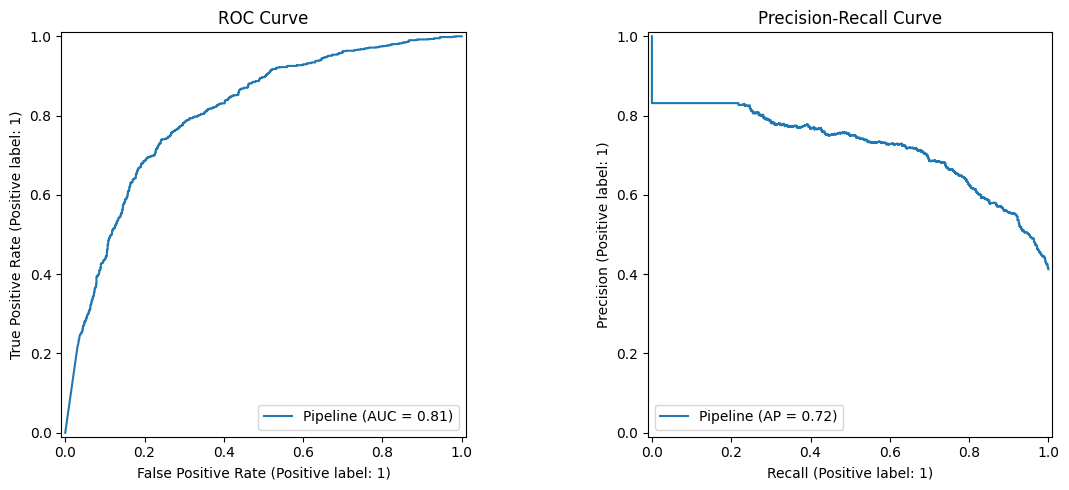

--- LogReg ---
Metrics for Pipeline:
    accuracy: 0.753
   precision: 0.694
      recall: 0.720
          f1: 0.707
     roc_auc: 0.813
      pr_auc: 0.740
         mcc: 0.494


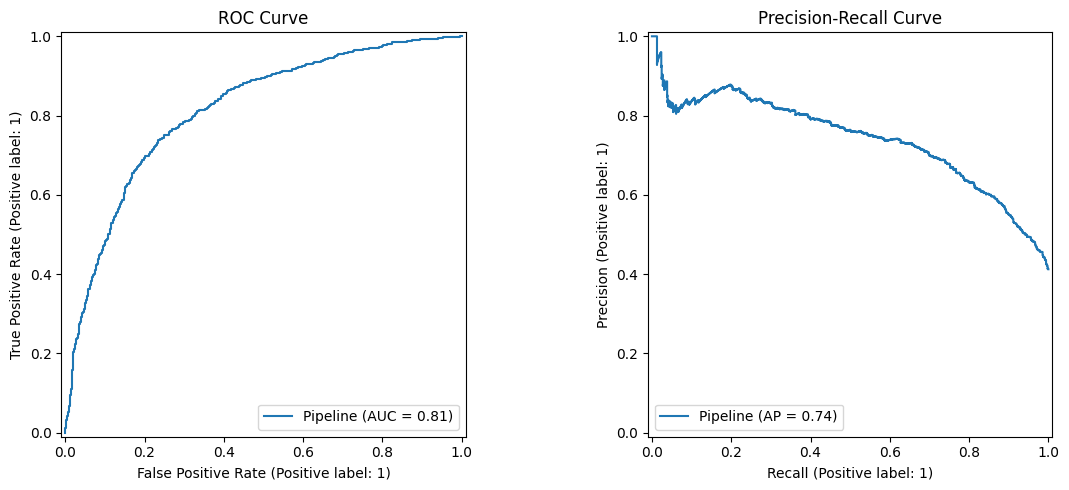

--- RF ---
Metrics for RandomForestClassifier:
    accuracy: 0.790
   precision: 0.824
      recall: 0.622
          f1: 0.709
     roc_auc: 0.876
      pr_auc: 0.838
         mcc: 0.563


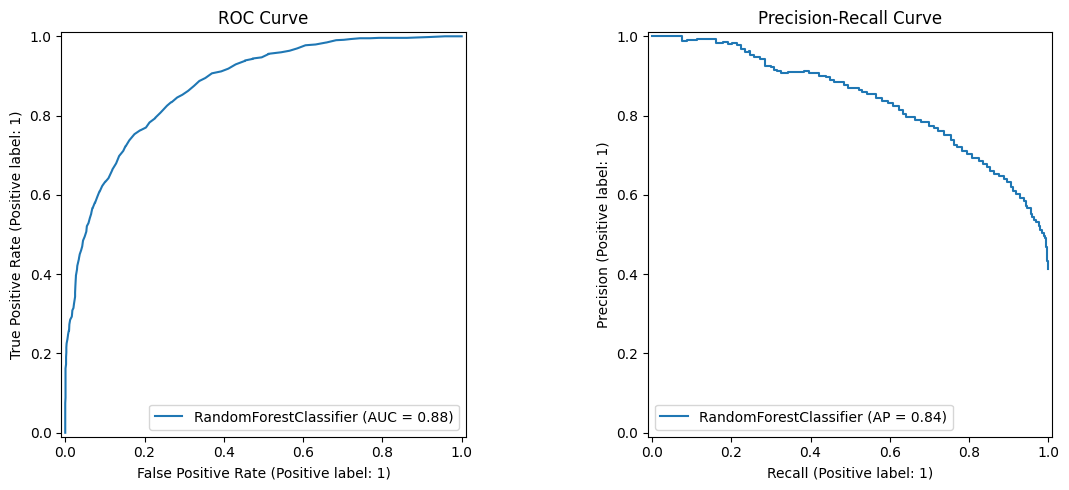


Feature importances:


1750    0.014581
1088    0.009847
1603    0.009145
1536    0.008262
875     0.007548
          ...   
483     0.000016
1935    0.000016
683     0.000014
1010    0.000010
498     0.000009
Length: 2048, dtype: float64

--- SVM ---
Metrics for Pipeline:
    accuracy: 0.793
   precision: 0.796
      recall: 0.670
          f1: 0.727
     roc_auc: 0.875
      pr_auc: 0.838
         mcc: 0.568


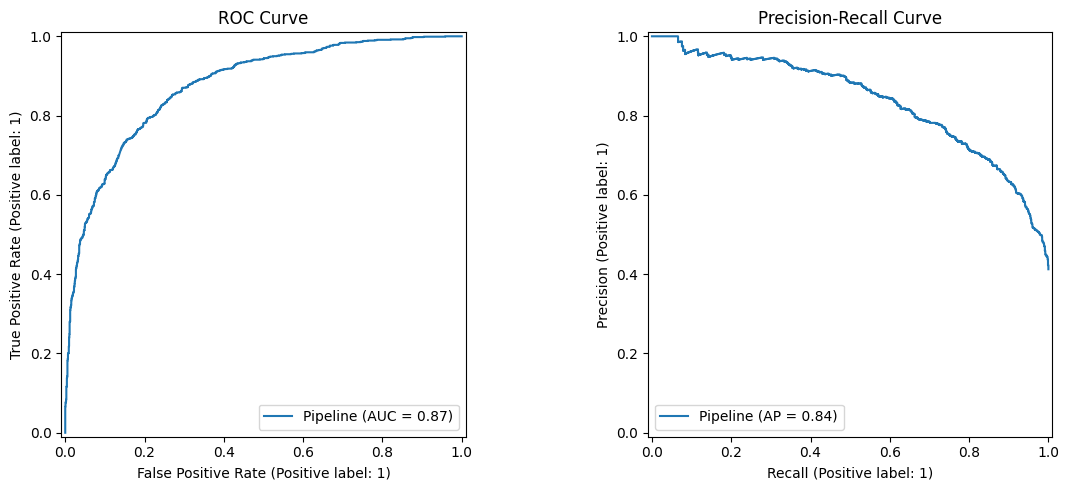


## 🔬 Isoforme: CYP1A2_Veith
  • Train labels: 0→4745, 1→4060,  ratio = 0.46
  •  Test labels: 0→1328, 1→1188,  ratio = 0.47

--- SGD ---
Metrics for Pipeline:
    accuracy: 0.775
   precision: 0.757
      recall: 0.773
          f1: 0.765
     roc_auc: 0.833
      pr_auc: 0.780
         mcc: 0.550


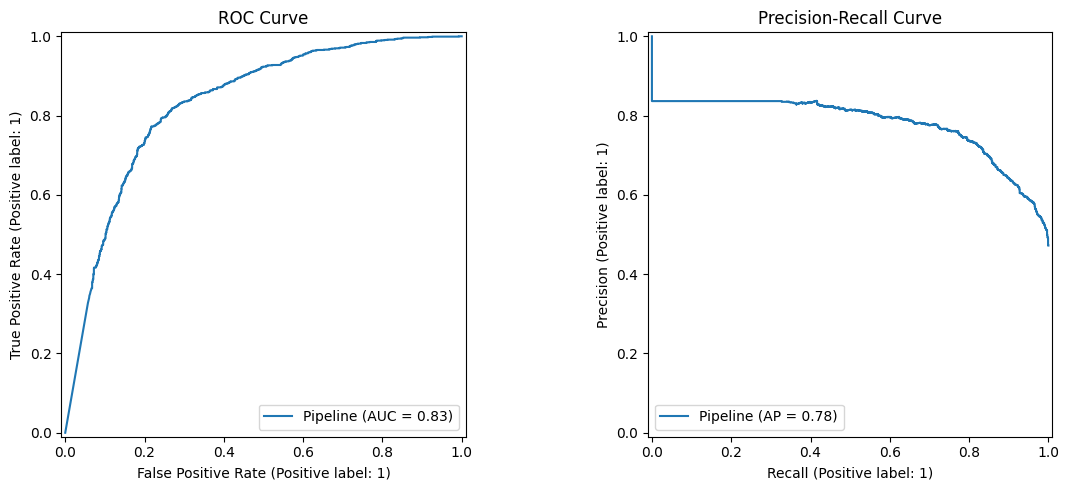

--- LogReg ---
Metrics for Pipeline:
    accuracy: 0.786
   precision: 0.768
      recall: 0.785
          f1: 0.776
     roc_auc: 0.843
      pr_auc: 0.799
         mcc: 0.572


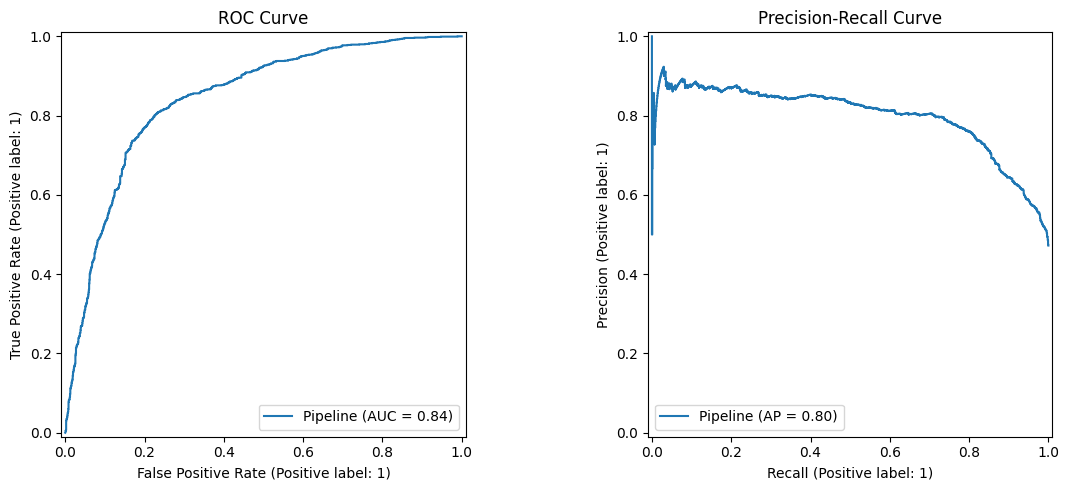

--- RF ---
Metrics for RandomForestClassifier:
    accuracy: 0.832
   precision: 0.838
      recall: 0.800
          f1: 0.818
     roc_auc: 0.917
      pr_auc: 0.912
         mcc: 0.663


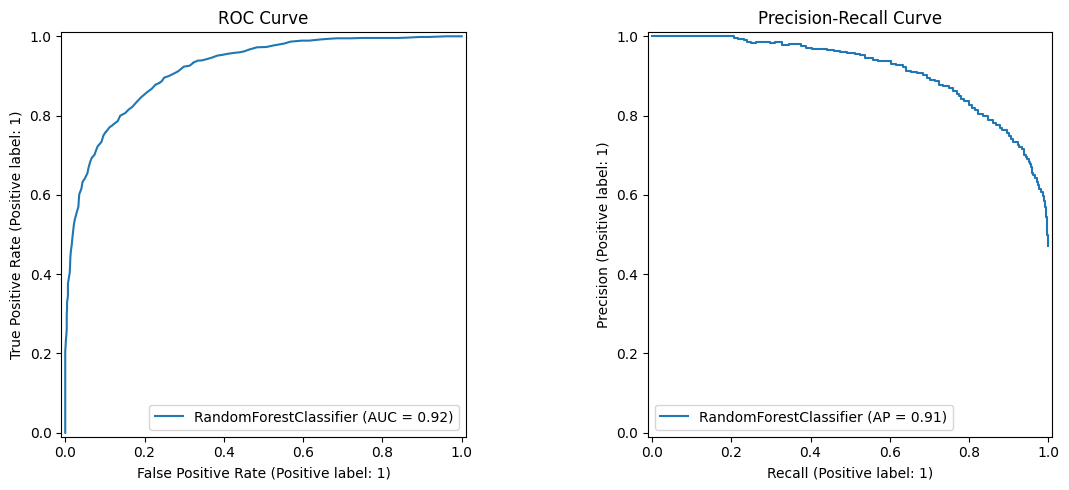


Feature importances:


807     0.015461
1019    0.014527
1097    0.013030
1750    0.012680
378     0.011409
          ...   
683     0.000016
1830    0.000015
109     0.000013
1545    0.000011
435     0.000007
Length: 2048, dtype: float64

--- SVM ---
Metrics for Pipeline:
    accuracy: 0.828
   precision: 0.837
      recall: 0.789
          f1: 0.812
     roc_auc: 0.911
      pr_auc: 0.905
         mcc: 0.654


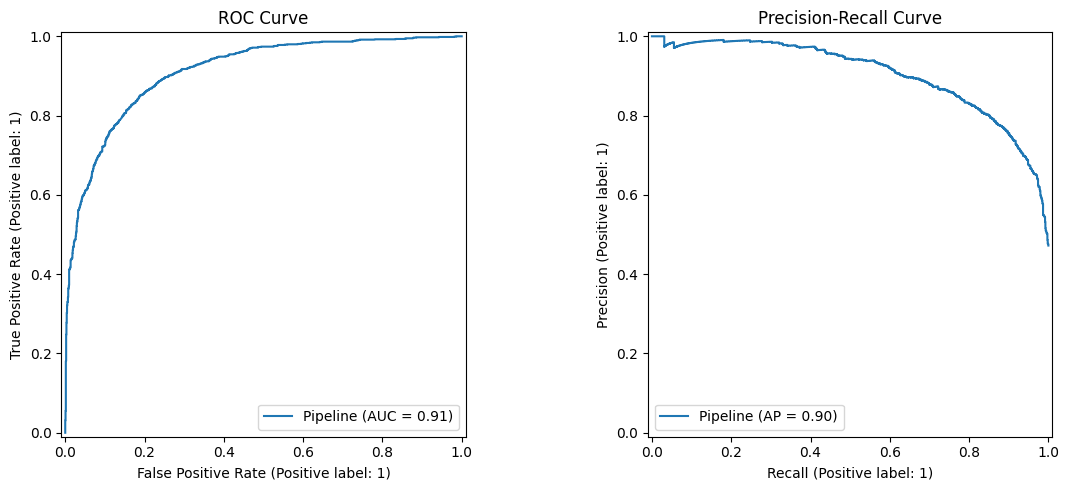


## 🔬 Isoforme: CYP2C9_Veith
  • Train labels: 0→5652, 1→2813,  ratio = 0.33
  •  Test labels: 0→1599, 1→819,  ratio = 0.34

--- SGD ---
Metrics for Pipeline:
    accuracy: 0.756
   precision: 0.641
      recall: 0.634
          f1: 0.637
     roc_auc: 0.799
      pr_auc: 0.656
         mcc: 0.453


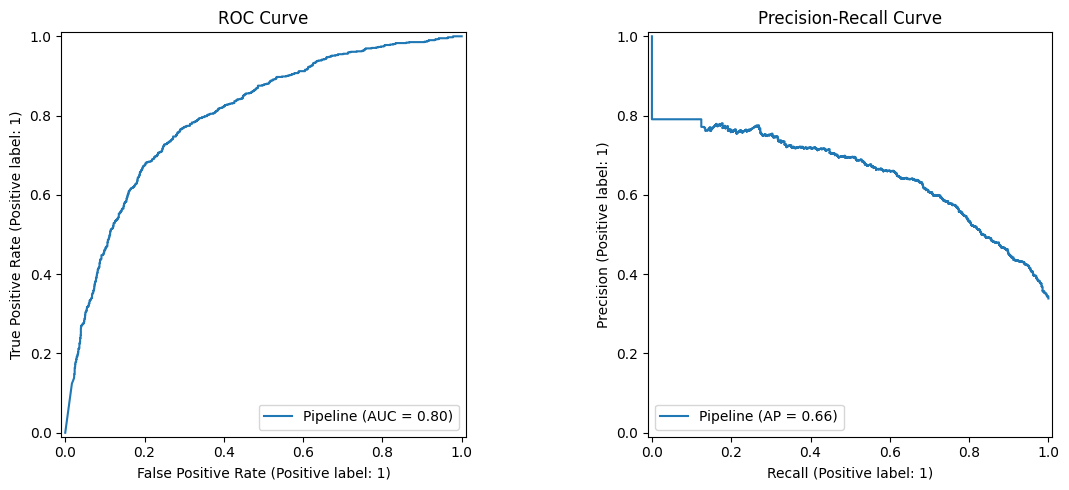

--- LogReg ---
Metrics for Pipeline:
    accuracy: 0.772
   precision: 0.666
      recall: 0.654
          f1: 0.660
     roc_auc: 0.813
      pr_auc: 0.683
         mcc: 0.488


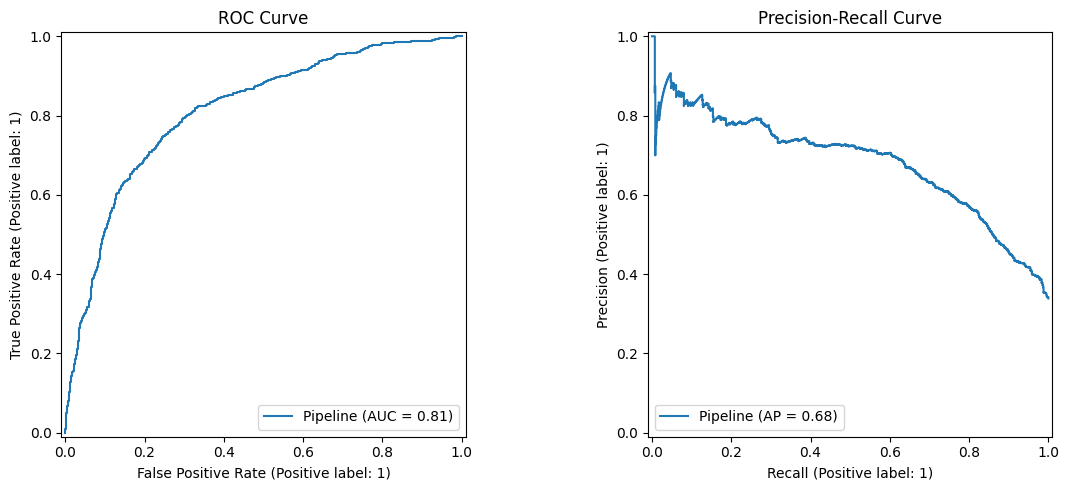

--- RF ---
Metrics for RandomForestClassifier:
    accuracy: 0.800
   precision: 0.792
      recall: 0.554
          f1: 0.652
     roc_auc: 0.881
      pr_auc: 0.783
         mcc: 0.534


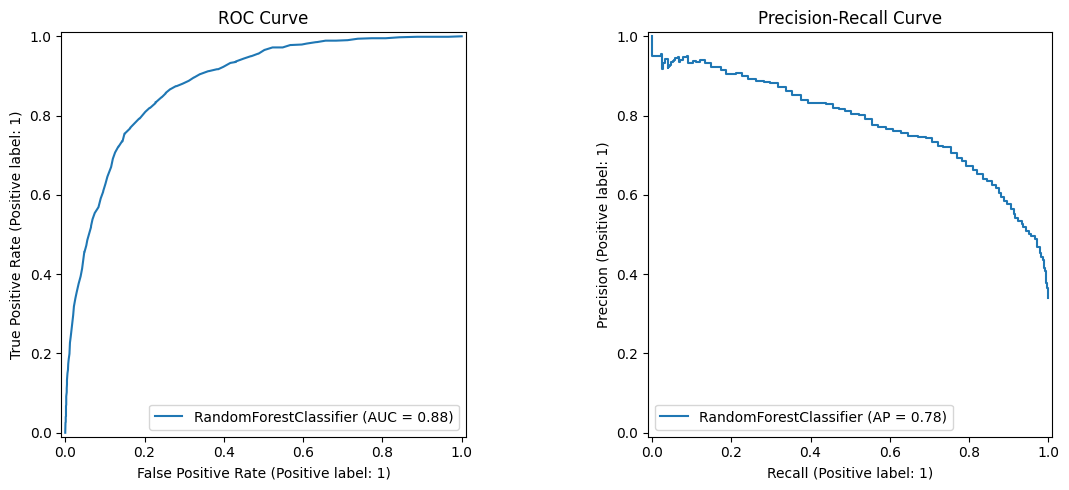


Feature importances:


1750    0.010827
1088    0.009145
675     0.006521
1683    0.006346
1199    0.005564
          ...   
435     0.000013
55      0.000011
572     0.000007
545     0.000006
1500    0.000005
Length: 2048, dtype: float64

--- SVM ---
Metrics for Pipeline:
    accuracy: 0.816
   precision: 0.793
      recall: 0.619
          f1: 0.695
     roc_auc: 0.880
      pr_auc: 0.784
         mcc: 0.576


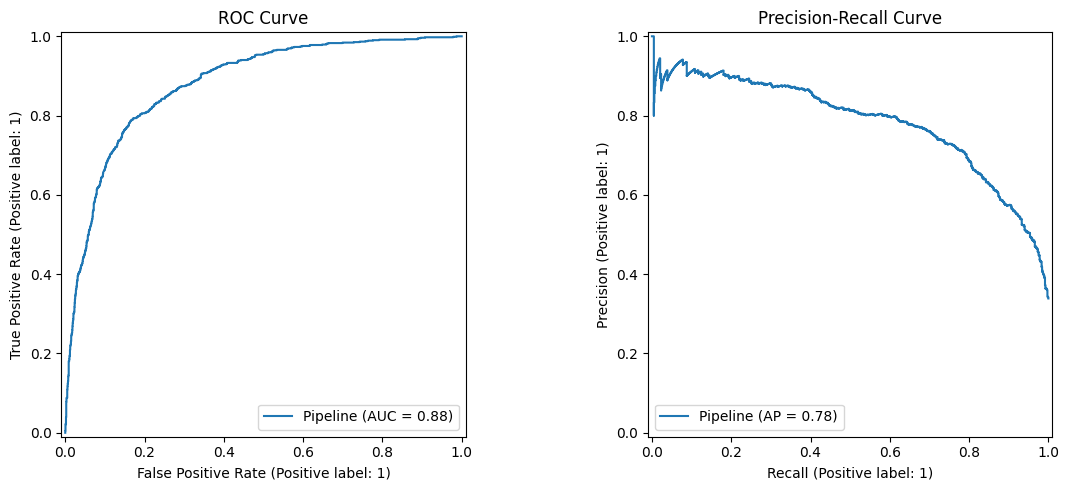

In [4]:
# %% [code]
from src.modeling import train_all_models, evaluate_model
import pandas as pd

# on va remplir ce dict {(isozyme, model): scores_dict}
results = {}

for isozyme, (X_tr, y_tr, X_te, y_te) in feature_sets.items():
    print(f"\n## 🔬 Isoforme: {isozyme}")
    # 1) distribution des labels
    neg, pos = (y_tr==0).sum(), (y_tr==1).sum()
    print(f"  • Train labels: 0→{neg}, 1→{pos},  ratio = {pos/(neg+pos):.2f}")
    neg, pos = (y_te==0).sum(), (y_te==1).sum()
    print(f"  •  Test labels: 0→{neg}, 1→{pos},  ratio = {pos/(neg+pos):.2f}\n")
    
    # 2) Train all models (sans gridsearch pour aller vite)
    models = train_all_models(X_tr, y_tr, param_grids=None)
    
    # 3) Evaluate each
    for name, model in models.items():
        print(f"--- {name} ---")
        # disable plotting to accélérer ; on peut repasser plot_curves=True si besoin
        scores = evaluate_model(model, X_te, y_te,
                                feature_names=X_tr.columns.tolist(),
                                plot_curves=True)
        results[(isozyme, name)] = scores


In [5]:
# %% [code]
# transforme le dict en DataFrame multi‐indexé
df_res = (
    pd.DataFrame(results)
      .T
      .rename_axis(index=['isozyme','model'])
      .reset_index()
)
# pivote pour avoir les modèles en colonnes
summary = df_res.pivot(index='isozyme', columns='model')
display(summary)


accuracy                               precision            \
model            LogReg        RF       SGD       SVM    LogReg        RF   
isozyme                                                                     
CYP1A2_Veith   0.786169  0.832273  0.775437  0.827504  0.767710  0.837743   
CYP2C19_Veith  0.744966  0.805764  0.729964  0.806553  0.729370  0.769478   
CYP2C9_Veith   0.771712  0.799835  0.755583  0.816377  0.665839  0.792321   
CYP2D6_Veith   0.812643  0.866717  0.816832  0.868621  0.496429  0.802632   
CYP3A4_Veith   0.753447  0.789538  0.748175  0.792782  0.693839  0.824219   

                                     recall            ...   roc_auc  \
model               SGD       SVM    LogReg        RF  ...       SGD   
isozyme                                                ...             
CYP1A2_Veith   0.756801  0.836607  0.784512  0.799663  ...  0.832601   
CYP2C19_Veith  0.715184  0.789338  0.706793  0.823732  ...  0.787121   
CYP2C9_Veith   0.640741  0.793427  0.654457  0.554335  ...  0.799123   
CYP2D6_Veith   0.506823  0.829493  0.569672  0.375000  ...  0.778135   
CYP3A4_Veith   0.684015  0.795561  0.719764  0.622419  ...  0.806472   

                           pr_auc                                     mcc  \
model               SVM    LogReg        RF       SGD       SVM    LogReg   
isozyme                                                                     
CYP1A2_Veith   0.910758  0.798706  0.912362  0.779817  0.904846  0.571626   
CYP2C19_Veith  0.880084  0.763688  0.841645  0.748883  0.845453  0.485500   
CYP2C9_Veith   0.880164  0.682735  0.782729  0.655580  0.784088  0.488303   
CYP2D6_Veith   0.856198  0.459185  0.669218  0.443079  0.671596  0.415723   
CYP3A4_Veith   0.874835  0.740489  0.837516  0.721573  0.838420  0.494347   

                                             
model                RF       SGD       SVM  
isozyme                                      
CYP1A2_Veith   0.663315  0.550088  0.653857  
CYP2C19_Veith  0.612276  0.454888  0.610506  
CYP2C9_Veith   0.534138  0.452941  0.575830  
CYP2D6_Veith   0.488952  0.406611  0.496648  
CYP3A4_Veith   0.562609  0.485441  0.567536  

[5 rows x 28 columns]

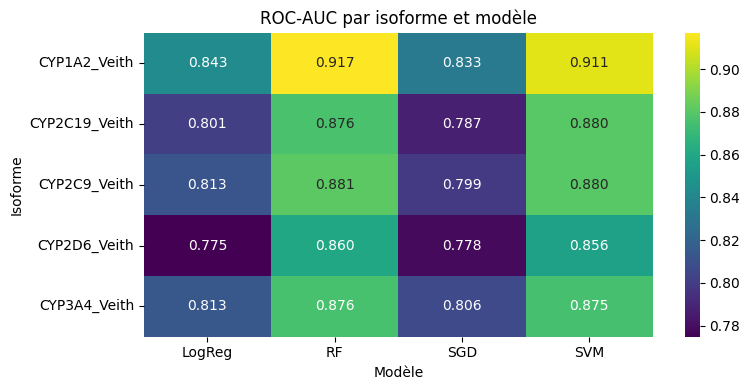

In [6]:
# %% [code]
import seaborn as sns
import matplotlib.pyplot as plt

# extraire la matrice ROC‑AUC
roc_mat = summary['roc_auc']
# heatmap
plt.figure(figsize=(8,4))
sns.heatmap(roc_mat, annot=True, fmt=".3f", cmap="viridis")
plt.title("ROC‑AUC par isoforme et modèle")
plt.ylabel("Isoforme")
plt.xlabel("Modèle")
plt.tight_layout()
plt.show()


In [7]:
# %% [code]
best_per_iso = (  # DataFrame qui, pour chaque isoforme, indique le modèle avec la meilleure ROC‑AUC
    roc_mat
    .idxmax(axis=1)
    .rename("best_model")
    .to_frame()
)
display(best_per_iso)


,best_model
isozyme,
CYP1A2_Veith,RF
CYP2C19_Veith,SVM
CYP2C9_Veith,RF
CYP2D6_Veith,RF
CYP3A4_Veith,RF


In [8]:
# %% [code]
import pandas as pd
from functools import reduce
from pathlib import Path

# 1) Mapping isoforme → fichier
data_dir = Path("data")
iso_files = {
    "CYP1A2":  data_dir / "cyp1a2_veith.tab",
    "CYP2C19": data_dir / "cyp2c19_veith.tab",
    "CYP2C9":  data_dir / "cyp2c9_veith.tab",
    "CYP2D6":  data_dir / "cyp2d6_veith.tab",
    "CYP3A4":  data_dir / "cyp3a4_veith.tab",
}

# 2) Charger chaque fichier et renommer les colonnes
dfs = []
for iso, path in iso_files.items():
    df = pd.read_csv(path, sep="\t")
    # Ajuster ces noms selon ton fichier (vérifie df.columns)
    # Ici on suppose qu’il y a 'Drug' (SMILES) et 'Y' (label 0/1)
    df = df.rename(columns={"Drug": "smiles", "Y": iso})
    dfs.append(df[["smiles", iso]])

# 3) Fusionner tous les DataFrames sur 'smiles'
df_all = reduce(lambda a, b: pd.merge(a, b, on="smiles", how="outer"), dfs)

# 4) Remplacer NaN→0 et convertir en int
df_all = df_all.fillna(0)
for iso in iso_files:
    df_all[iso] = df_all[iso].astype(int)

print(f"✅ Dataset multi‑label fusionné : {df_all.shape[0]} molécules × {len(iso_files)} isoformes")
df_all.head()


✅ Dataset multi‑label fusionné : 16366 molécules × 5 isoformes


,smiles,CYP1A2,CYP2C19,CYP2C9,CYP2D6,CYP3A4
0,Br.Brc1ccc(C2=Nn3c(nnc3-c3cccnc3)SC2)s1,1,0,0,0,1
1,Br.C/C(=N/NC1=NCCN1)c1cn(C2=NCCN2)nc1C,0,0,0,0,0
2,Br.CC(C)CC1CC(=O)OC1(C)C(=O)CSc1nc2ccccc2s1,1,1,1,0,1
3,Br.CC(NC1=NCCCCC1)c1ccccc1,0,0,0,1,0
4,Br.CC1(C(=O)CSc2nc3ccccc3s2)CCC(=O)O1,0,1,0,0,0


In [9]:
# %% [code]
# 5) Featurisation : ECFP4 pour chaque smiles
from src.preprocessing import compute_ecfp4

print("🔄 Featurisation ECFP4…")
fps = df_all["smiles"].apply(compute_ecfp4)
X = pd.DataFrame(fps.tolist())
print(f"   ▶️ Shape X: {X.shape}")

# 6) Préparer Y (DataFrame multi‑label)
Y = df_all[list(iso_files.keys())]
print(f"   ▶️ Shape Y: {Y.shape} (labels 0/1 par isoforme)")


🔄 Featurisation ECFP4…
   ▶️ Shape X: (16366, 2048)
   ▶️ Shape Y: (16366, 5) (labels 0/1 par isoforme)


### Comparaison OvR vs Chain

### One‑Vs‑Rest (OvR)

- Chaque isoforme « i » a son propre classifieur indépendant ; une molécule peut être prédite inhibitrice d’aucune, d’une ou de plusieurs isoformes.

### ClassifierChain

- Chaque classifieur apprend à la fois sur X et sur les prédictions des isoformes précédentes ; cela modélise les dépendances entre isoformes.

In [10]:
# %% [code]
# 7) Split train/test
from src.cyp_modeling import multilabel_train_test_split
X_tr, X_te, Y_tr, Y_te = multilabel_train_test_split(X, Y, test_size=0.2, random_state=42)
print(f"   ▶️ X_train={X_tr.shape}, Y_train={Y_tr.shape}")
print(f"   ▶️ X_test ={X_te.shape}, Y_test ={Y_te.shape}")


   ▶️ X_train=(13092, 2048), Y_train=(13092, 5)
   ▶️ X_test =(3274, 2048), Y_test =(3274, 5)


,Hamming Loss,Subset Accuracy,ROC-AUC (macro),Precision (macro),Recall (macro),F1 (macro)
OvR,0.202,0.414,0.840,0.725,0.409,0.507
Chain,0.208,0.424,0.839,0.738,0.373,0.484


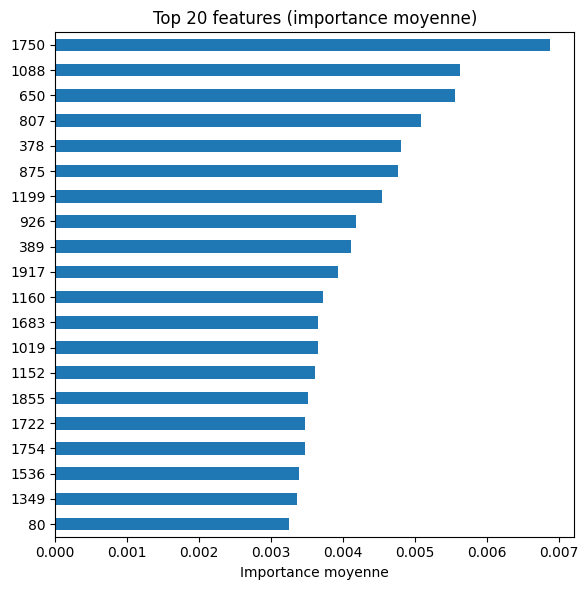

Metrics for RandomForestClassifier:
    accuracy: 0.804
   precision: 0.759
      recall: 0.626
          f1: 0.686
     roc_auc: 0.874
      pr_auc: 0.792
         mcc: 0.551


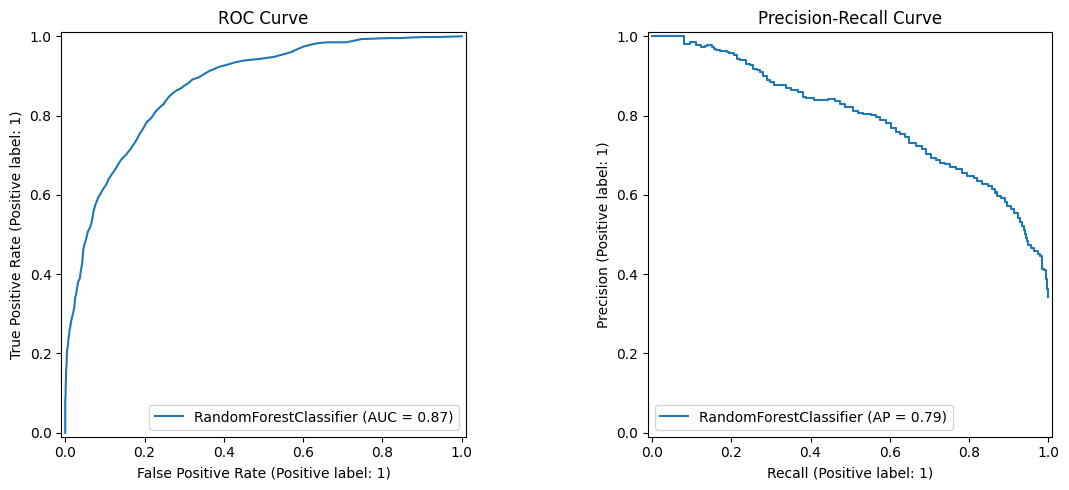


Feature importances:


807     0.012483
926     0.009517
378     0.009306
1019    0.009285
650     0.007901
          ...   
874     0.000020
752     0.000019
1772    0.000019
498     0.000017
616     0.000017
Length: 2048, dtype: float64

In [11]:
# %% [code]  ###############################################################
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    hamming_loss, accuracy_score, roc_auc_score,
    precision_score, recall_score, f1_score
)
from src.cyp_modeling import train_and_evaluate_cyp
from src.modeling     import evaluate_model          # pour courbes ROC/PR

# ---------- 1) Entraînement ------------------------------------------------
models = {
    'OvR'  : train_and_evaluate_cyp(X_tr, Y_tr, method='ovr'),
    'Chain': train_and_evaluate_cyp(X_tr, Y_tr, method='chain')
}

targets = list(Y_tr.columns)      # noms des isoformes
metrics = {}

# ---------- 2) Boucle d’évaluation ----------------------------------------
for name, clf in models.items():
    # Prédictions binaires
    Y_pred = clf.predict(X_te)

    # Probabilités de la classe positive pour chaque isoforme
    proba_raw = clf.predict_proba(X_te)

    # Normalisation : obtenir une matrice (n_samples, n_labels)
    if isinstance(proba_raw, list):                       # ex. ClassifierChain
        proba_mat = np.column_stack([p[:, 1] for p in proba_raw])
    elif proba_raw.ndim == 3:                             # (n, labels, 2)
        proba_mat = proba_raw[:, :, 1]
    elif proba_raw.shape[1] == 2 * len(targets):          # (n, 2*labels)
        proba_mat = proba_raw[:, 1::2]
    else:                                                 # déjà (n, labels)
        proba_mat = proba_raw

    proba_df = pd.DataFrame(proba_mat, columns=targets, index=X_te.index)

    # Métriques macro
    metrics[name] = {
        'Hamming Loss'      : hamming_loss(Y_te, Y_pred),
        'Subset Accuracy'   : accuracy_score(Y_te, Y_pred),
        'ROC-AUC (macro)'   : roc_auc_score(Y_te, proba_df, average='macro'),
        'Precision (macro)' : precision_score(Y_te, Y_pred, average='macro'),
        'Recall (macro)'    : recall_score(Y_te, Y_pred, average='macro'),
        'F1 (macro)'        : f1_score(Y_te, Y_pred, average='macro')
    }

# ---------- 3) Tableau récapitulatif --------------------------------------
df_metrics = pd.DataFrame(metrics).T.round(3)
display(df_metrics)

# ---------- 4) Importance moyenne des features (optionnel) ----------------
base_est = models['OvR'].estimators_[0]
if hasattr(base_est, "feature_importances_"):
    importances = pd.Series(0.0, index=X_tr.columns, dtype=float)
    for est in models['OvR'].estimators_:
        importances += est.feature_importances_
    importances /= len(models['OvR'].estimators_)

    topn = 20
    (importances.sort_values(ascending=False)
                .head(topn)[::-1]                 # barh = du moins au plus
                .plot.barh(figsize=(6, 6)))
    plt.title(f'Top {topn} features (importance moyenne)')
    plt.xlabel('Importance moyenne')
    plt.tight_layout()
    plt.show()

# ---------- 5) (Facultatif) courbes ROC/PR pour une isoforme --------------
# Exemple : la première isoforme avec le modèle OvR
_ = evaluate_model(
        models['OvR'].estimators_[0],
        X_te,
        Y_te.iloc[:, 0],
        feature_names=X_tr.columns,
        plot_curves=True
    )
###########################################################################


In [12]:
!pip install shap

  Using cached numpy-2.1.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (16.3 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.3.1
    Uninstalling numpy-2.3.1:
      Successfully uninstalled numpy-2.3.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cellxgene-census 1.15.0 requires numpy<2.0,>=1.21, but you have numpy 2.1.3 which is incompatible.
pytdc 1.1.15 requires numpy<2.0.0,>=1.26.4, but you have numpy 2.1.3 which is incompatible.
accelerate 0.33.0 requires numpy<2.0.0,>=1.17, but you have numpy 2.1.3 which is incompatible.
tiledb 0.29.1 requires numpy<2.0,>=1.25; python_version >= "3.9", but you have numpy 2.1.3 which is incompatible.


In [20]:
# %% [code] — featurisation des hits & TKIs en ECFP4
import pandas as pd
from src.preprocessing import process_smiles, compute_ecfp4

def featurize_df(df, smiles_col='smiles_clean', already_clean=True):
    """
    Convertit un DataFrame de SMILES en matrice de fingerprints ECFP4.
    
    Parameters
    ----------
    df : pd.DataFrame
        Doit contenir la colonne `smiles_col`.
    smiles_col : str
        Nom de la colonne où se trouvent les SMILES.
    already_clean : bool
        Si False, applique process_smiles avant le fingerprint.

    Returns
    -------
    X : pd.DataFrame  # shape = (n_mols, 2048)
    df_out : pd.DataFrame  # df enrichi de la colonne 'fp'
    """
    if not already_clean:
        df['smiles_clean'] = df[smiles_col].map(process_smiles)
    else:
        df['smiles_clean'] = df[smiles_col]

    removed = df['smiles_clean'].isna().sum()
    df.dropna(subset=['smiles_clean'], inplace=True)
    print(f"{len(df)} SMILES valides (–{removed} NaN)")

    df['fp'] = df['smiles_clean'].map(compute_ecfp4)
    X = pd.DataFrame(df['fp'].tolist(), index=df.index)   # 2048 colonnes
    return X, df

# -------------------------------------------------------------------------
# 1) Charger les fichiers
DATA_DIR = Path("artifacts")
TKI_DIR = Path("data")

hits_df = pd.read_csv(DATA_DIR /"04_consensus_detailed.csv")   # 64 hits
tkis_df = pd.read_csv(TKI_DIR /"tkis.csv")                    # 4 TKIs approuvés

# 2) Featuriser
X_hits, hits_df = featurize_df(hits_df, smiles_col='smiles_clean', already_clean=True)
X_tkis, tkis_df = featurize_df(tkis_df, smiles_col='smiles', already_clean=True)

print("Shapes  ➜  X_hits:", X_hits.shape, " |  X_tkis:", X_tkis.shape)


64 SMILES valides (–0 NaN)
4 SMILES valides (–0 NaN)
Shapes  ➜  X_hits: (64, 2048)  |  X_tkis: (4, 2048)


In [22]:
# %% [code] — prédiction CYP sur les hits & TKIs
import numpy as np
import pandas as pd

# ------------------------- paramètres ------------------------------------
MODEL      = models['OvR']          # modèle entraîné plus haut
THRESHOLD  = 0.5                    # change si tu as un best_thr optimisé
ISOFORMS   = list(Y_tr.columns)     # ex. ['CYP1A2','CYP2C9', …]

# ------------------------- fonction utilitaire ---------------------------
def predict_multilabel(clf, X, thr=0.5):
    """retourne proba_df, pred_df à partir d'un modèle multilabel."""
    proba_raw = clf.predict_proba(X)

    # normalise -> matrice (n_samples, n_labels)
    if isinstance(proba_raw, list):
        proba_mat = np.column_stack([p[:, 1] for p in proba_raw])
    elif proba_raw.ndim == 3:
        proba_mat = proba_raw[:, :, 1]
    elif proba_raw.shape[1] == 2 * len(ISOFORMS):
        proba_mat = proba_raw[:, 1::2]
    else:
        proba_mat = proba_raw

    proba_df = pd.DataFrame(proba_mat,
                            columns=[iso + "_prob" for iso in ISOFORMS])
    pred_df  = (proba_mat >= thr).astype(int)
    pred_df  = pd.DataFrame(pred_df, columns=ISOFORMS)
    return proba_df, pred_df

# ------------------------- HITS ------------------------------------------
proba_hits, pred_hits = predict_multilabel(MODEL, X_hits, THRESHOLD)
hits_out = pd.concat([hits_df.reset_index(drop=True),
                      proba_hits, pred_hits], axis=1)
hits_out.to_csv("hits_with_CYP_predictions.csv", index=False)
print("✅ 64 hits ⇒ hits_with_CYP_predictions.csv")

# ------------------------- TKIs ------------------------------------------
proba_tkis, pred_tkis = predict_multilabel(MODEL, X_tkis, THRESHOLD)
tkis_out = pd.concat([tkis_df.reset_index(drop=True),
                      proba_tkis, pred_tkis], axis=1)
tkis_out.to_csv("tkis_with_CYP_predictions.csv", index=False)
print("✅ 4 TKIs ⇒ tkis_with_CYP_predictions.csv")

# ------------------------- résumés rapides -------------------------------
print("\n📊 Compte des inhibiteurs prédits (hits) :")
print(pred_hits.sum().sort_values(ascending=False))

print("\n📊 Compte des inhibiteurs prédits (TKIs) :")
print(pred_tkis.sum().sort_values(ascending=False))


✅ 64 hits ⇒ hits_with_CYP_predictions.csv
✅ 4 TKIs ⇒ tkis_with_CYP_predictions.csv

📊 Compte des inhibiteurs prédits (hits) :
CYP3A4     38
CYP1A2     35
CYP2C19     8
CYP2C9      4
CYP2D6      2
dtype: int64

📊 Compte des inhibiteurs prédits (TKIs) :
CYP3A4     3
CYP1A2     2
CYP2C19    1
CYP2C9     0
CYP2D6     0
dtype: int64


In [24]:
# Ex. filtrer les hits « propres » (aucune inhibition prédite)
safe_hits = hits_out[pred_hits.sum(axis=1) == 0]
safe_hits


,chembl_id,tki,MW,LogP,HBA,HBD,tanimoto_consensus,scaffold,smiles_clean,fp,CYP1A2_prob,CYP2C19_prob,CYP2C9_prob,CYP2D6_prob,CYP3A4_prob,CYP1A2,CYP2C19,CYP2C9,CYP2D6,CYP3A4
2,CHEMBL2347958,Afatinib,485.947000,4.38990,7,2,1.000000,c1ccc(Nc2ncnc3cc(O[C@@H]4CCOC4)ccc23)cc1,CN(C)C/C=C/C(=O)NC1=CC2=C(NC3=CC=C(F)C(Cl)=C3)...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.48,0.460,0.48,0.250000,0.380000,0,0,0,0,0
3,CHEMBL4759112,Afatinib,485.947000,4.38990,7,2,0.930075,c1ccc(Nc2ncnc3ccc(O[C@@H]4CCOC4)cc23)cc1,CN(C)C/C=C/C(=O)NC1=CC2=NC=NC(NC3=CC=C(F)C(Cl)...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.49,0.460,0.49,0.240000,0.390000,0,0,0,0,0
8,CHEMBL3622629,Afatinib,428.851000,4.45810,6,2,0.788348,c1ccc(Nc2ncnc3cc(O[C@H]4CCOC4)ccc23)cc1,C=CC(=O)NC1=CC2=C(NC3=CC=C(F)C(Cl)=C3)N=CN=C2C...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.47,0.460,0.42,0.190000,0.470000,0,0,0,0,0
13,CHEMBL31965,Gefitinib,485.947000,4.39150,7,2,0.731004,c1ccc(Nc2ncnc3cc(OCCCN4CCOCC4)ccc23)cc1,C=CC(=O)NC1=CC2=C(NC3=CC=C(F)C(Cl)=C3)N=CN=C2C...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...",0.31,0.360,0.42,0.390000,0.400000,0,0,0,0,0
25,CHEMBL474524,Gefitinib,470.932000,4.68030,6,1,0.667388,c1ccc2c(-c3ncnc4ccc(OCCCN5CCOCC5)cc34)c[nH]c2c1,COC1=CC2=NC=NC(C3=CNC4=CC(F)=C(Cl)C=C43)=C2C=C...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...",0.46,0.260,0.28,0.370000,0.330000,0,0,0,0,0
26,CHEMBL2064372,Gefitinib,457.893000,3.79610,8,1,0.663833,O=c1oc2cc3ncnc(Nc4ccccc4)c3cc2n1CCCN1CCOCC1,O=C1OC2=CC3=NC=NC(NC4=CC=C(F)C(Cl)=C4)=C3C=C2N...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.47,0.350,0.36,0.310000,0.440000,0,0,0,0,0
27,CHEMBL299893,Gefitinib,480.924000,2.20080,9,4,0.662877,c1ccc(Nc2ncnc3ccccc23)cc1,COC1=CC2=NC=NC(NC3=CC=C(F)C(Cl)=C3)=C2C=C1OCC(...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.43,0.360,0.39,0.350000,0.460000,0,0,0,0,0
28,CHEMBL3647422,Afatinib,499.974000,4.78000,7,2,0.652197,O=C(/C=C/[C@H]1CCCN1)Nc1ccc2ncnc(Nc3ccccc3)c2c1,COCCOC1=CC2=NC=NC(NC3=CC=C(F)C(Cl)=C3)=C2C=C1N...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...",0.36,0.416,0.32,0.220000,0.470000,0,0,0,0,0
32,CHEMBL2441565,Afatinib,441.894000,4.00910,6,1,0.618438,c1ccc(Nc2ncnc3cc4c(cc23)NCCO4)cc1,CN(C)C/C=C/C(=O)N1CCOC2=CC3=NC=NC(NC4=CC=C(F)C...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.46,0.340,0.39,0.286667,0.370000,0,0,0,0,0
37,CHEMBL2441561,Gefitinib,483.931000,3.77970,7,1,0.592217,O=C(/C=C/CN1CCOCC1)N1CCOc2cc3ncnc(Nc4ccccc4)c3...,O=C(/C=C/CN1CCOCC1)N1CCOC2=CC3=NC=NC(NC4=CC=C(...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.40,0.360,0.38,0.277333,0.430000,0,0,0,0,0


In [28]:
# Tri par risque cumulé (somme des probabilités)
hits_out['risk_score'] = proba_hits.sum(axis=1)
prioritized = hits_out.sort_values('risk_score')

# Export
safe_hits.to_csv("hits_safe.csv", index=False)
prioritized.to_csv("hits_prioritized.csv", index=False)

print(f"{len(safe_hits)} molécules sans inhibition prédite.")
print("10 molécules les + sûres :")
display(prioritized.head(10))

19 molécules sans inhibition prédite.
10 molécules les + sûres :


,chembl_id,tki,MW,LogP,HBA,HBD,tanimoto_consensus,scaffold,smiles_clean,fp,...,CYP2C19_prob,CYP2C9_prob,CYP2D6_prob,CYP3A4_prob,CYP1A2,CYP2C19,CYP2C9,CYP2D6,CYP3A4,risk_score
63,CHEMBL3926191,Osimertinib,417.469000,3.18710,6,3,0.389670,c1ccc(-c2cc3n(n2)C(c2ccccc2)CCN3)cc1,C=CC(=O)NC1=CC=CC=C1C1CCNC2=C(C(N)=O)C(C3=CC=C...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",...,0.27,0.35,0.1025,0.400000,0,0,0,0,0,1.482500
51,CHEMBL5269375,Osimertinib,486.576000,3.92590,9,1,0.505184,c1ccc2c(-c3ccnc(Nc4ccc(N5CCNCC5)cc4)n3)c[nH]c2c1,COC(=O)C1=CN=C(NC2=CC=C(N3CCN(C)CC3)C=C2OC)N=C...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ...",...,0.36,0.21,0.1900,0.390000,0,0,0,0,0,1.510000
43,CHEMBL5394752,Osimertinib,497.621305,4.80480,8,2,0.558055,c1ccc2c(-c3ccnc(Nc4ccc5[nH]ncc5c4)n3)c[nH]c2c1,[2H]C([2H])([2H])N1C=C(C2=CC=NC(NC3=CC(NC(=O)/...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",...,0.29,0.24,0.2300,0.370000,0,0,0,0,0,1.530000
61,CHEMBL2437479,Osimertinib,414.425000,3.05240,8,2,0.395381,O=c1cnc2cnc(Nc3ccccc3)nc2n1-c1ccccc1,C=CC(=O)NC1=CC=CC(N2C(=O)C=NC3=CN=C(NC4=CC=C(O...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",...,0.13,0.20,0.1500,0.540000,1,0,0,0,1,1.550000
60,CHEMBL3890068,Osimertinib,461.522000,3.20370,7,3,0.398622,c1ccc(-c2cc3n(n2)C(c2ccccc2)CCN3)cc1,C=CC(=O)NC1=CC=CC=C1C1CCNC2=C(C(N)=O)C(C3=CC=C...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...",...,0.28,0.44,0.1165,0.430000,0,0,0,0,0,1.586500
55,CHEMBL1229592,Osimertinib,494.983000,4.55080,8,2,0.447120,c1ccc(Oc2ccnc(Nc3ccc(N4CCNCC4)cc3)n2)cc1,C=CC(=O)NC1=CC=CC(OC2=NC(NC3=CC=C(N4CCN(C)CC4)...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ...",...,0.46,0.27,0.1200,0.433333,0,0,0,0,0,1.623333
25,CHEMBL474524,Gefitinib,470.932000,4.68030,6,1,0.667388,c1ccc2c(-c3ncnc4ccc(OCCCN5CCOCC5)cc34)c[nH]c2c1,COC1=CC2=NC=NC(C3=CNC4=CC(F)=C(Cl)C=C43)=C2C=C...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...",...,0.26,0.28,0.3700,0.330000,0,0,0,0,0,1.700000
1,CHEMBL3353410,Osimertinib,499.619000,4.50980,8,2,1.000000,c1ccc(Nc2nccc(-c3c[nH]c4ccccc34)n2)cc1,C=CC(=O)NC1=CC(NC2=NC=CC(C3=CN(C)C4=CC=CC=C34)...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",...,0.38,0.14,0.2300,0.540000,0,0,0,0,1,1.720000
48,CHEMBL5397162,Osimertinib,485.610305,4.63870,8,2,0.530107,c1ccc2c(-c3ccnc(Nc4ccc5[nH]ncc5c4)n3)c[nH]c2c1,[2H]C([2H])([2H])N1C=C(C2=CC=NC(NC3=CC(NC(=O)C...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",...,0.37,0.34,0.2400,0.420000,0,0,0,0,0,1.770000
38,CHEMBL27688,Gefitinib,447.539000,3.90742,7,2,0.584709,c1ccc(Nc2ncnc3cc(OCCCN4CCOCC4)ccc23)cc1,C=CC(=O)NC1=CC2=C(NC3=CC=CC(C)=C3)N=CN=C2C=C1O...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...",...,0.36,0.30,0.3100,0.460000,0,0,0,0,0,1.770000
